In [1]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

path = "../data/formatted_trial_exp1.csv"
df = pd.read_csv(path)

In [3]:
response_id = "R_9OwRUAA1BoKmvhl"
target_col = "Affect Level"

In [4]:
distribution = (
    df
    .groupby("responseId")[target_col]
    .value_counts(dropna=False)
    .rename("count")
    .reset_index()
    .sort_values("count", ascending=False)
)

distribution

,responseId,Affect Level,count
1781,R_9OwRUAA1BoKmvhl,70.0,92
2014,R_9dukvbnZkwMhA8D,50.0,84
1956,R_9d3P33wTPvC95vK,50.0,67
1276,R_98CCmrZLuPem2Z1,100.0,55
0,R_406piivDmShdVkR,60.0,54
...,...,...,...
957,R_4n351uZ4A3tUc7u,42.0,1
956,R_4n351uZ4A3tUc7u,21.0,1
955,R_4n351uZ4A3tUc7u,44.0,1
954,R_4n351uZ4A3tUc7u,43.0,1


In [5]:
distribution = (
    df.loc[
        df["responseId"] == response_id,
        target_col
    ]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

distribution

Affect Level
10.0     2.0
40.0     4.0
60.0     2.0
70.0    92.0
Name: proportion, dtype: float64

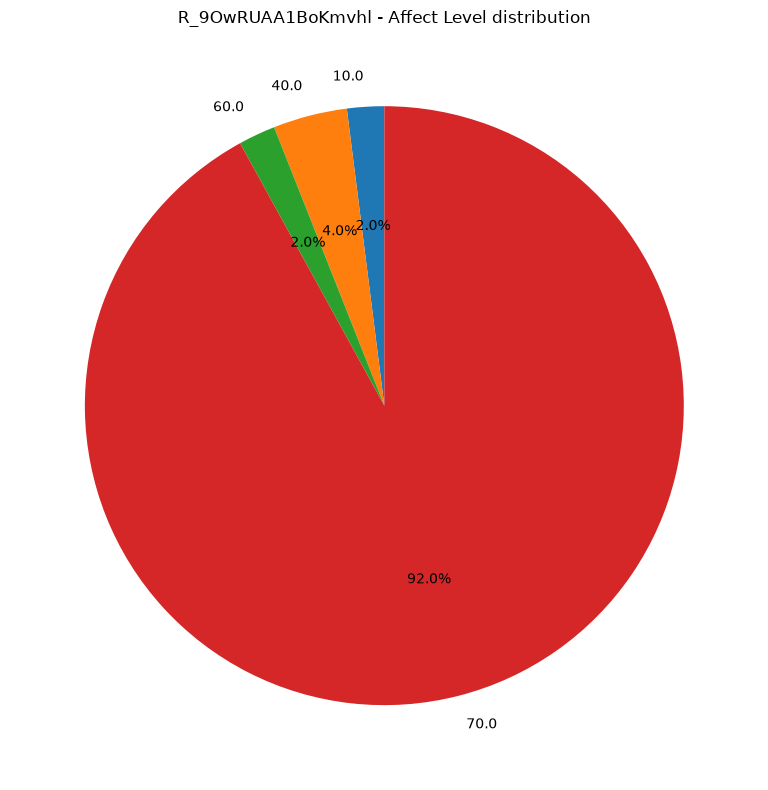

In [6]:
counts = (
    df.loc[
        df["responseId"] == response_id,
        target_col
    ]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8, 8))

plt.pie(
    counts.values,
    labels=counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(f"{response_id} - {target_col} distribution")

plt.tight_layout()
plt.show()

In [7]:
max_counts = (
    df
    .groupby("responseId")[target_col]
    .value_counts()
    .groupby(level=0)
    .max()
    .rename("max_count")
    .reset_index()
    .sort_values("max_count", ascending=False)
)

max_counts

,responseId,max_count
68,R_9OwRUAA1BoKmvhl,92
80,R_9dukvbnZkwMhA8D,84
77,R_9d3P33wTPvC95vK,67
51,R_98CCmrZLuPem2Z1,55
0,R_406piivDmShdVkR,54
...,...,...
15,R_4MF4HRuNuNnlO2T,5
17,R_4Odoqj3Shd741LE,5
31,R_4l6l7Hlm3o0SkDf,5
56,R_9GkRReOr9w2wwyZ,5


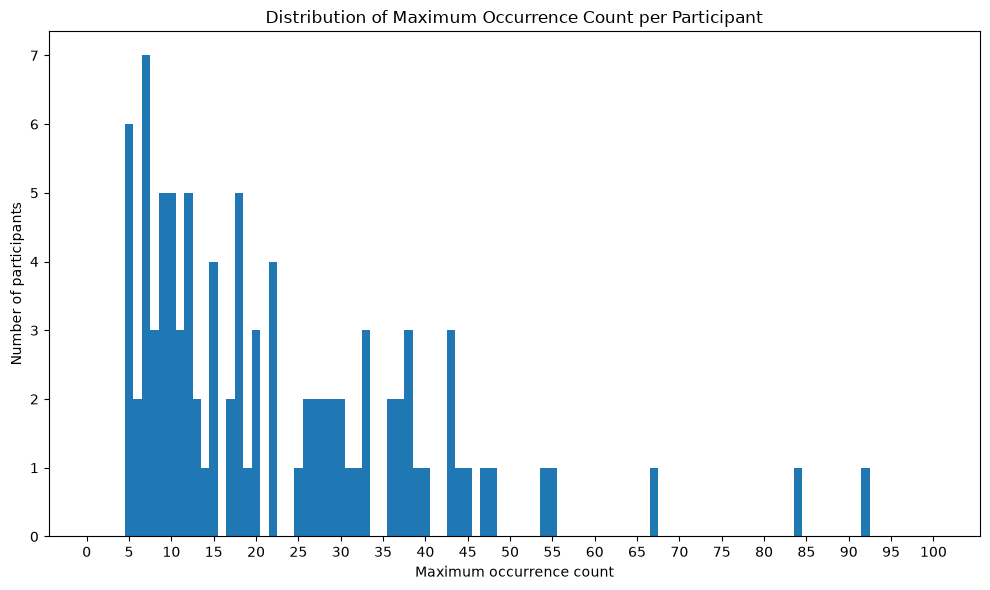

In [8]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.hist(
    max_counts["max_count"],
    bins=np.arange(0.5, 101.5, 1)
)

plt.xlabel("Maximum occurrence count")
plt.ylabel("Number of participants")
plt.title("Distribution of Maximum Occurrence Count per Participant")

plt.xticks(np.arange(0, 101, 5))

plt.tight_layout()
plt.show()

In [9]:
upper_95 = max_counts["max_count"].quantile(0.95)

print("95%点:", upper_95)

95%点: 49.79999999999998
